# Projet MLOps — Prédiction du défaut de crédit

**Objectif.** Construire un modèle de scoring crédit qui estime la **probabilité de défaut (PD)** pour chaque client à partir de variables tabulaires (revenu, dette, ancienneté, score FICO, etc.).  
Des prédictions fiables aident la banque à dimensionner le capital pour couvrir les pertes attendues et à stabiliser le risque.

**Plan.**
1) EDA rapide & préparation,
2) Feature engineering léger (ratio dette/revenu),
3) Prétraitement dans un **pipeline** (imputation médiane, scaling seulement pour les modèles linéaires),
4) Entraînement de 3 modèles (Logistic, Decision Tree, Random Forest) + **tracking MLflow**,
5) Sélection sur **val_roc_auc**, sérialisation du pipeline,
6) Démo d’inférence avec **Streamlit** .

## 1) Exploration rapide (EDA) & chargement

On inspecte la structure du dataset, la qualité des variables et la distribution de la **cible** `default`.  
> Le dataset est entièrement numérique et propre ; on privilégiera AUC-ROC / Recall / F1 (jeu légèrement déséquilibré).


In [ ]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
import mlflow

# Chargement
df = pd.read_csv("Loan_Data.csv")
df.head()


,customer_id,credit_lines_outstanding,loan_amt_outstanding,total_debt_outstanding,income,years_employed,fico_score,default
0,8153374,0,5221.545193,3915.471226,78039.38546,5,605,0
1,7442532,5,1958.928726,8228.752520,26648.43525,2,572,1
2,2256073,0,3363.009259,2027.830850,65866.71246,4,602,0
3,4885975,0,4766.648001,2501.730397,74356.88347,5,612,0
4,4700614,1,1345.827718,1768.826187,23448.32631,6,631,0


In [27]:
print(df.info())
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   customer_id               10000 non-null  int64  
 1   credit_lines_outstanding  10000 non-null  int64  
 2   loan_amt_outstanding      10000 non-null  float64
 3   total_debt_outstanding    10000 non-null  float64
 4   income                    10000 non-null  float64
 5   years_employed            10000 non-null  int64  
 6   fico_score                10000 non-null  int64  
 7   default                   10000 non-null  int64  
dtypes: float64(3), int64(5)
memory usage: 625.1 KB
None


,customer_id,credit_lines_outstanding,loan_amt_outstanding,total_debt_outstanding,income,years_employed,fico_score,default
count,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,4.974577e+06,1.461200,4159.677034,8718.916797,70039.901401,4.552800,637.557700,0.185100
std,2.293890e+06,1.743846,1421.399078,6627.164762,20072.214143,1.566862,60.657906,0.388398
min,1.000324e+06,0.000000,46.783973,31.652732,1000.000000,0.000000,408.000000,0.000000
25%,2.977661e+06,0.000000,3154.235371,4199.836020,56539.867903,3.000000,597.000000,0.000000
50%,4.989502e+06,1.000000,4052.377228,6732.407217,70085.826330,5.000000,638.000000,0.000000
75%,6.967210e+06,2.000000,5052.898103,11272.263740,83429.166133,6.000000,679.000000,0.000000
max,8.999789e+06,5.000000,10750.677810,43688.784100,148412.180500,10.000000,850.000000,1.000000


### Taux de défaut et implications métriques

On calcule le **taux de défaut** (proportion de `default = 1`).  
Comme le dataset est déséquilibré (~18,5%), on se focalise sur **AUC-ROC**, **Recall** et **F1**, plutôt que l’accuracy seule.


Taux de défaut : 18.51%


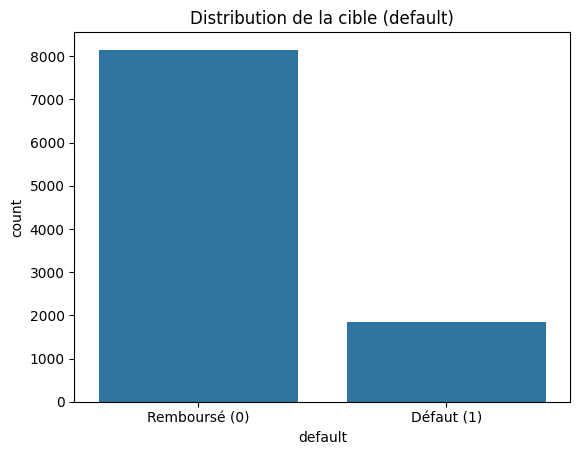

In [28]:
taux_defaut = df['default'].mean() * 100
print(f"Taux de défaut : {taux_defaut:.2f}%")

sns.countplot(x='default', data=df)
plt.title("Distribution de la cible (default)")
plt.xticks([0,1], ['Remboursé (0)', 'Défaut (1)'])
plt.show()


### Variables explicatives clés

- **FICO score** plus bas chez les clients en défaut → fort pouvoir discriminant.
- Variables financières (dette/encours/revenu) pertinentes → **on les conserve toutes**.


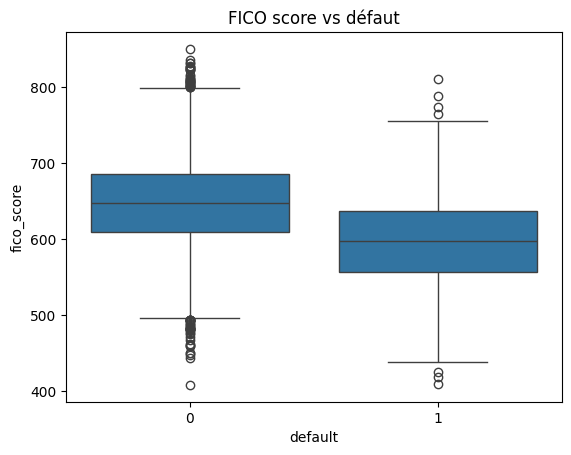

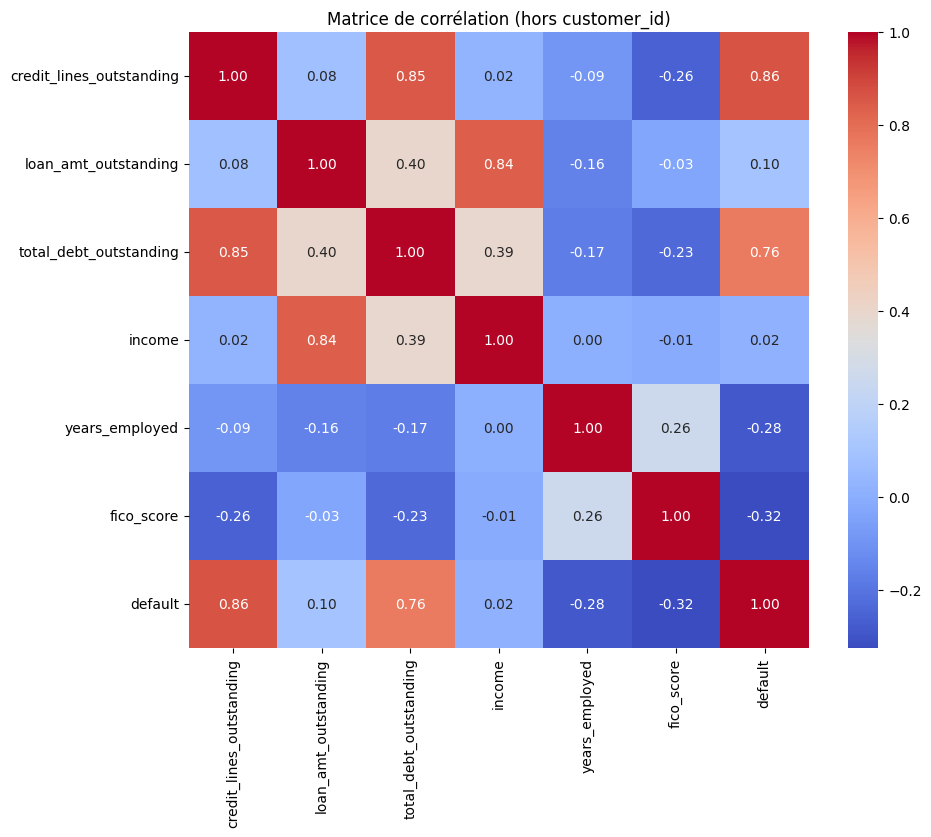

In [29]:
sns.boxplot(x='default', y='fico_score', data=df)
plt.title('FICO score vs défaut')
plt.show()

corr = df.drop(columns=['customer_id']).corr()
plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Matrice de corrélation (hors customer_id)')
plt.show()


## 2) Feature engineering & séparation X/y (dans un module réutilisable)

On crée une feature robuste et standard en scoring crédit :  

**Formule :**  
`debt_income_variable = total_debt_outstanding / (income + ε)`

Cette variable représente le niveau d’endettement relatif au revenu.  
> **Remarque :** on ne supprime **aucune variable financière**, contrairement à certains exemples.


In [31]:
def load_data(path: str):
    df = pd.read_csv(path)

    # Feature engineering léger : ratio dette/revenu (protégé contre division par zéro)
    eps = 1e-5
    df["debt_income_variable"] = df["total_debt_outstanding"] / (df["income"] + eps)

    # Cible binaire et séparation X/y
    y = df["default"].astype(int)

    # On retire uniquement la cible et l'ID non prédictif
    X = df.drop(columns=["default", "customer_id"], errors="ignore")
    return X, y

def make_splits(X, y, test_size=0.2, val_size=0.2, random_state=42):
    # Train / Temp (stratification pour conserver ~18.5% défaut)
    X_train, X_temp, y_train, y_temp = train_test_split(
        X, y, test_size=test_size, stratify=y, random_state=random_state
    )
    # Val / Test à 50/50 sur le reste, toujours stratifié
    X_val, X_test, y_val, y_test = train_test_split(
        X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=random_state
    )
    return X_train, X_val, X_test, y_train, y_val, y_test

In [33]:
X, y = load_data("Loan_Data.csv")
X_train, X_val, X_test, y_train, y_val, y_test = make_splits(X, y)
X.head(), y.head()



(   credit_lines_outstanding  loan_amt_outstanding  total_debt_outstanding  \
 0                         0           5221.545193             3915.471226   
 1                         5           1958.928726             8228.752520   
 2                         0           3363.009259             2027.830850   
 3                         0           4766.648001             2501.730397   
 4                         1           1345.827718             1768.826187   
 
         income  years_employed  fico_score  debt_income_variable  
 0  78039.38546               5         605              0.050173  
 1  26648.43525               2         572              0.308789  
 2  65866.71246               4         602              0.030787  
 3  74356.88347               5         612              0.033645  
 4  23448.32631               6         631              0.075435  ,
 0    0
 1    1
 2    0
 3    0
 4    0
 Name: default, dtype: int64)

> Les splits sont **stratifiés** sur `y` pour conserver le ~18,5% de défaut dans train/val/test.


## 3) Prétraitement dans le pipeline

On intègre le **prétraitement directement dans le pipeline scikit-learn** :
- **Imputation médiane** (sécurité, même si pas de NA ici),
- **Standardisation** uniquement pour la **régression logistique** (modèle sensible à l’échelle).

> Cela évite la **fuite de données** et garantit la **reproductibilité** (entraînement & inférence).


In [34]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

In [35]:
def numeric_pipeline(with_scaler: bool = True):
    steps = [("imputer", SimpleImputer(strategy="median"))]
    if with_scaler:
        steps.append(("scaler", StandardScaler()))
    return Pipeline(steps)

In [ ]:
def build_model(kind: str):
    if kind == "logistic":
        clf = LogisticRegression(max_iter=200)
        pre = numeric_pipeline(with_scaler=True)    # scaling utile
    elif kind == "tree":
        clf = DecisionTreeClassifier(max_depth=6, random_state=42)
        pre = numeric_pipeline(with_scaler=False)   
    elif kind == "rf":
        clf = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
        pre = numeric_pipeline(with_scaler=False)   
    else:
        raise ValueError("kind must be in {logistic, tree, rf}")
    return Pipeline([("prep", pre), ("clf", clf)])

## 4) Entraînement des modèles & suivi MLflow

On entraîne 3 modèles :
- **Logistic Regression** (baseline),
- **Decision Tree**,
- **Random Forest**.

Chaque exécution est trackée dans **MLflow** (paramètres, métriques, artefacts).  
On sélectionne le **meilleur modèle** sur **`val_roc_auc`** et on enregistre le pipeline complet (`best_model.joblib`).


In [37]:
import os, joblib, mlflow
import numpy as np
from sklearn.metrics import roc_auc_score, f1_score, precision_score, recall_score, accuracy_score


In [38]:
def compute_metrics(y_true, y_prob, threshold=0.5):
    """Calcule les métriques clés à partir des probabilités de classe 1."""
    y_pred = (y_prob >= threshold).astype(int)
    return {
        "roc_auc": roc_auc_score(y_true, y_prob),
        "accuracy": accuracy_score(y_true, y_pred),
        "f1": f1_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred),
        "recall": recall_score(y_true, y_pred),
    }


In [39]:
# 1) Définir l'expérience MLflow
experiment_name = "CreditScoring"
mlflow.set_experiment(experiment_name)

2025/10/13 22:35:02 INFO mlflow.tracking.fluent: Experiment with name 'CreditScoring' does not exist. Creating a new experiment.


<Experiment: artifact_location='file:///Users/hugob/Desktop/DAta/MLOPS/MLOps/mlruns/353841605726091991', creation_time=1760391302442, experiment_id='353841605726091991', last_update_time=1760391302442, lifecycle_stage='active', name='CreditScoring', tags={}>

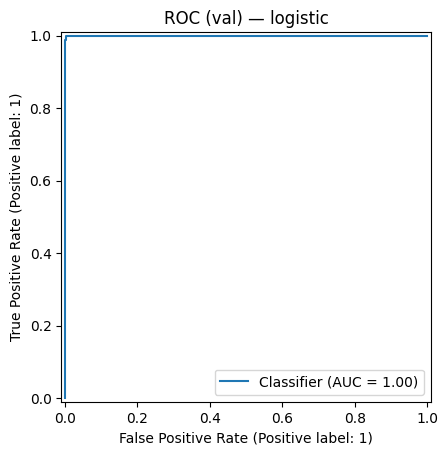

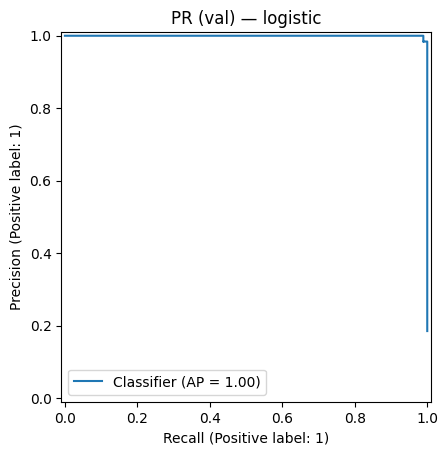

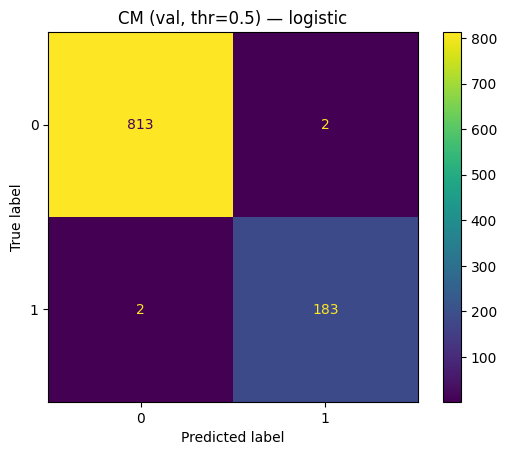

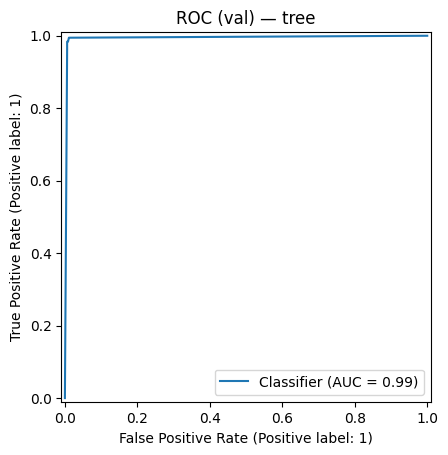

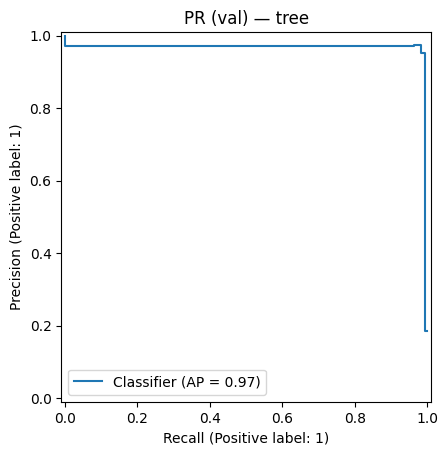

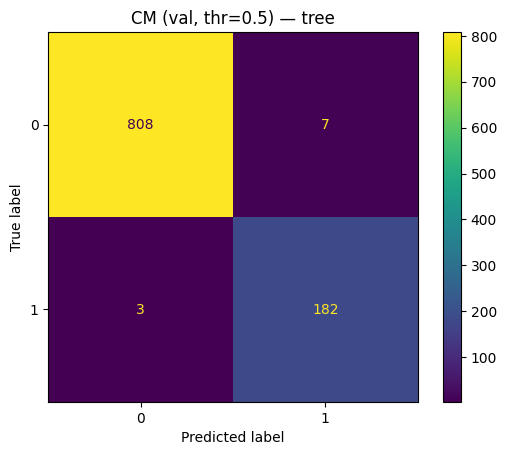

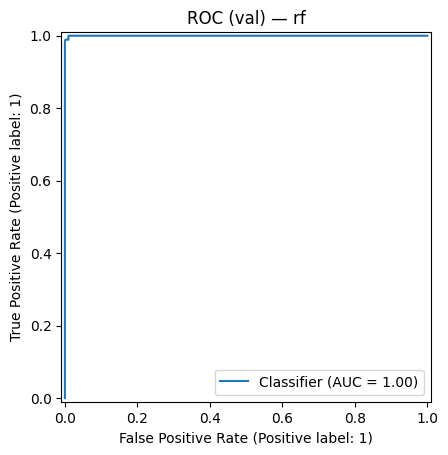

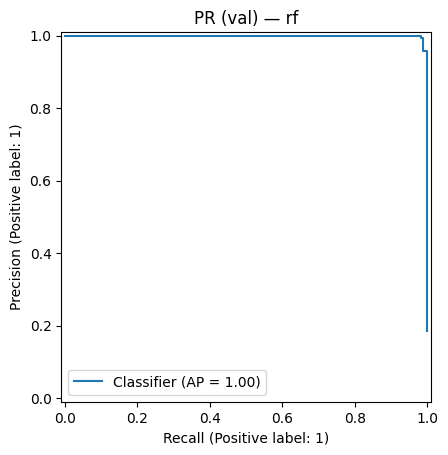

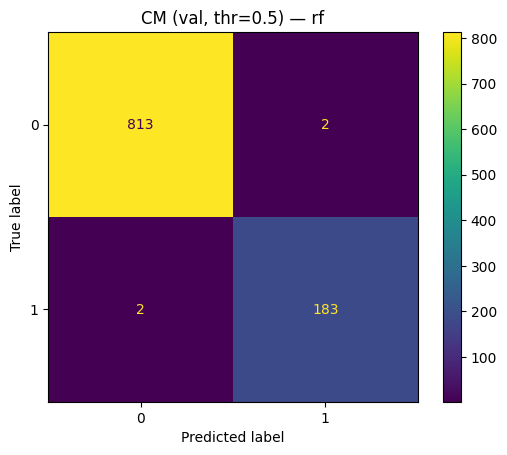

In [42]:
# 2) Entraîner les candidats et logger
candidates = ["logistic", "tree", "rf"]
results = []
os.makedirs("models", exist_ok=True)

for kind in candidates:
    with mlflow.start_run(run_name=kind):
        # a) paramètres utiles à tracer
        mlflow.log_param("model", kind)
        mlflow.log_param("n_features", int(X.shape[1]))
        mlflow.log_param("features", ",".join(X.columns))

        # b) construction et entraînement du pipeline
        model = build_model(kind)
        model.fit(X_train, y_train)

        # c) éval: proba de la classe 1 (défaut)
        val_prob  = model.predict_proba(X_val)[:, 1]
        test_prob = model.predict_proba(X_test)[:, 1]

        val_m  = compute_metrics(y_val,  val_prob)
        test_m = compute_metrics(y_test, test_prob)

        # >>> VISU (VALIDATION) — À INSÉRER ICI, juste après val_prob / val_m
        from sklearn.metrics import RocCurveDisplay, PrecisionRecallDisplay, ConfusionMatrixDisplay
        import matplotlib.pyplot as plt

        # ROC (val)
        fig, ax = plt.subplots()
        RocCurveDisplay.from_predictions(y_val, val_prob, ax=ax)
        ax.set_title(f'ROC (val) — {kind}')
        mlflow.log_figure(fig, f'roc_val_{kind}.png'); plt.show(); plt.close(fig)

        # Precision–Recall (val)
        fig, ax = plt.subplots()
        PrecisionRecallDisplay.from_predictions(y_val, val_prob, ax=ax)
        ax.set_title(f'PR (val) — {kind}')
        mlflow.log_figure(fig, f'pr_val_{kind}.png'); plt.show(); plt.close(fig)

        # Matrice de confusion (val, thr=0.5)
        y_val_pred = (val_prob >= 0.5).astype(int)
        fig, ax = plt.subplots()
        ConfusionMatrixDisplay.from_predictions(y_val, y_val_pred, ax=ax)
        ax.set_title(f'CM (val, thr=0.5) — {kind}')
        mlflow.log_figure(fig, f'cm_val_thr05_{kind}.png'); plt.show(); plt.close(fig)


        # d) logging des métriques
        for k, v in val_m.items():
            mlflow.log_metric(f"val_{k}", float(v))
        for k, v in test_m.items():
            mlflow.log_metric(f"test_{k}", float(v))

        # e) garder sous la main pour la sélection
        results.append({
            "kind": kind,
            "model": model,
            "val_roc_auc": float(val_m["roc_auc"]),
            "test_metrics": test_m
        })


In [43]:
# Audit "fuite potentielle" : AUC univariée de chaque feature vs y
import numpy as np, pandas as pd
from sklearn.metrics import roc_auc_score

def univariate_auc_report(X, y):
    aucs = {}
    for c in X.columns:
        x = X[c].values
        if np.unique(x).size < 2:
            continue
        try:
            auc = roc_auc_score(y, x)
            auc = max(auc, 1-auc)  # oriente toujours >= 0.5
            aucs[c] = auc
        except Exception:
            pass
    return pd.Series(aucs).sort_values(ascending=False)

report = univariate_auc_report(X, y)
display(report.head(15))


debt_income_variable        0.998272
credit_lines_outstanding    0.995650
total_debt_outstanding      0.963439
fico_score                  0.730693
years_employed              0.707271
loan_amt_outstanding        0.573939
income                      0.512246
dtype: float64

In [45]:
suspects = report[report > 0.99].index.tolist()
print("Suspects:", suspects)

import seaborn as sns, matplotlib.pyplot as plt
df_full = pd.read_csv("Loan_Data.csv")  # pour tracer
for c in suspects[:3]:
    sns.kdeplot(data=df_full, x=c, hue='default', common_norm=False)
    plt.title(f"{c} par défaut vs non défaut")
    plt.show()


Suspects: ['debt_income_variable', 'credit_lines_outstanding']


ValueError: Could not interpret value `debt_income_variable` for `x`. An entry with this name does not appear in `data`.

In [41]:
# 3) Sélection du meilleur modèle sur val_roc_auc
best = max(results, key=lambda d: d["val_roc_auc"])